In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from snake.snake_gym import Snake

from gymnasium.wrappers import FrameStackObservation, RecordVideo, RecordEpisodeStatistics
from gymnasium.vector import SyncVectorEnv

import numpy as np

import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter

import time
import matplotlib.pyplot as plt

In [ ]:
train_video_dir = f"../data/ppo/v1"
train_episodes = 1000
num_steps = 2048
num_envs = 8
stack_size = 4

In [ ]:
def make_env(idx: int, capture_video: bool = False):
    def thunk():
        env = Snake(truncation_steps=32000)
        
        env = FrameStackObservation(env, stack_size=stack_size)        
        env = RecordEpisodeStatistics(env=env)
        
        if capture_video and idx == 0:
            env = RecordVideo(env, train_video_dir, episode_trigger=lambda episode_id: episode_id % 100 == 0)
        return env
    return thunk

In [4]:
envs = SyncVectorEnv([make_env(idx, capture_video=False) for idx in range(num_envs)])

In [5]:
action_size = envs.single_action_space.n
action_size

np.int64(4)

In [6]:
envs.single_observation_space

Box(0.0, 3.0, (4, 30, 30), float32)

{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{'episode': {'r': array([0., 0., 0., 0., 1., 0., 0., 0.]), '_r': array([False, False, False, False,  True, False, False, False]), 'l': array([ 0,  0,  0,  0, 20,  0,  0,  0]), '_l': array([False, False, False, False,  True, False, False, False]), 't': array([0.      , 0.      , 0.      , 0.      , 0.008677, 0.      ,
       0.      , 0.      ]), '_t': array([False, False, False, False,  True, False, False, False])}, '_episode': array([False, False, False, False,  True, False, False, False])}
{}
{'episode': {'r': array([1., 0., 0., 0., 0., 0., 0., 0.]), '_r': array([ True, False, False, False, False, False, False, False]), 'l': array([22,  0,  0,  0,  0,  0,  0,  0]), '_l': array([ True, False, False, False, False, False, False, False]), 't': array([0.010059, 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      ]), '_t': array([ True, False, False, False, False, False, False, False])}, '_episode': array([ Tru

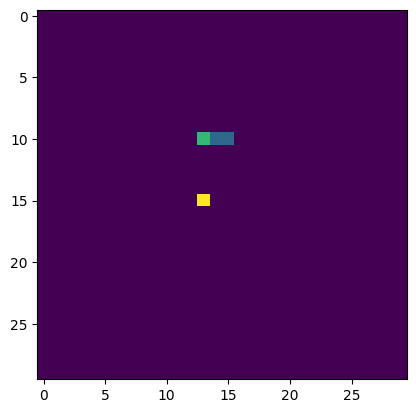

In [7]:
obs, _ = envs.reset(seed=42)
obs[0][0]

for i in range(100):
    obs, reward, terminations, truncations, infos = envs.step(envs.action_space.sample())
    print(infos)
        
    
plt.imshow(obs[0][0])

In [8]:
obs.shape

(8, 4, 30, 30)

In [9]:
obs = torch.as_tensor(obs, dtype=torch.float32)
obs.shape

torch.Size([8, 4, 30, 30])

In [10]:
cnn = nn.Sequential(
    nn.Conv2d(stack_size, 32, 3, 1, 1),
    nn.ReLU(),
    nn.Conv2d(32, 64, 3, 2, 1),
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, 2, 1),
    nn.ReLU(),
    
    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 512),
    nn.ReLU(),  
)
print(cnn(obs).shape)

torch.Size([8, 512])


In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer

class Agent(nn.Module):
    def __init__(self, n_hid, n_out):
        super().__init__()
        self.network = nn.Sequential(
            layer_init(nn.Conv2d(stack_size, 32, kernel_size=3, stride=1, padding=1)),
            nn.ReLU(),
            
            layer_init(nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)),
            nn.ReLU(),         
               
            layer_init(nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1)),
            nn.ReLU(),
            
            nn.Flatten(),
            layer_init(nn.Linear(64 * 8 * 8, n_hid)),
            nn.ReLU(),  
        )
        
        self.actor = layer_init(nn.Linear(n_hid, n_out), std=0.01)
        self.critic = layer_init(nn.Linear(n_hid, 1), std=1)                

    def get_value(self, x):
        return self.critic(self.network(x))

    def get_action_and_value(self, x, action=None):
        hidden = self.network(x)
        logits = self.actor(hidden)
        probs = torch.distributions.Categorical(logits=logits)
        if action is None:
            action = probs.sample()
        return action, probs.log_prob(action), probs.entropy(), self.critic(hidden)
    
def train(
    envs,
    model,
    optimizer,
    updates,
    update_epochs,
    num_steps,
    target_kl = 0.03,
    mini_batch_size = 64,
    gae_lambda = 0.95,
    clip_coef = 0.2,
    ent_coef = 0.01,
    vf_coef = 0.5,
    max_grad_norm = 0.5,
    norm_advantages = False,
    clip_vloss = False,
    lr_decay = False,
    gamma = 0.999,
    initial_lr = 1e-3,
    min_lr = 1e-5
):
    
    total_timesteps = updates * num_steps * num_envs
    
    writer = SummaryWriter(f"runs/snake-v10")
    
    batch_size = num_steps * num_envs
    
    obs = torch.zeros((num_steps, num_envs) + envs.single_observation_space.shape).to(device)
    actions = torch.zeros((num_steps, num_envs) + envs.single_action_space.shape, dtype=torch.long).to(device)
    logprobs = torch.zeros((num_steps, num_envs)).to(device)
    rewards = torch.zeros((num_steps, num_envs)).to(device)
    dones = torch.zeros((num_steps, num_envs)).to(device)
    values = torch.zeros((num_steps, num_envs)).to(device)
    
    global_step = 0
    next_obs, _ = envs.reset()
    next_obs = torch.Tensor(next_obs).to(device)
    next_done = torch.zeros(num_envs).to(device)
    start_time = time.time()
    
    for episode in range(1, updates + 1):      
        total_reward = 0
        
        if lr_decay:
            frac = max(
                0.0,
                1.0 - global_step / total_timesteps
            )

            lrnow = min_lr + frac * (initial_lr - min_lr)

            optimizer.param_groups[0]["lr"] = lrnow
        
        for step in range(0, num_steps):
            global_step += num_envs
            obs[step] = next_obs
            dones[step] = next_done
            
            with torch.no_grad():
                action, logprob, _, value = model.get_action_and_value(next_obs)
                values[step] = value.flatten()
            actions[step] = action
            logprobs[step] = logprob
            
            next_obs, reward, terminations, truncations, infos = envs.step(action.cpu().numpy())
            next_done = np.logical_or(terminations, truncations)
            rewards[step] = torch.tensor(reward).to(device).view(-1)
            total_reward += float(reward.mean())
            next_obs, next_done = torch.Tensor(next_obs).to(device), torch.tensor(next_done, dtype=torch.float32).to(device)
            
            if "episode" in infos:
                ep = infos["episode"]

                for reward, finished, length in zip(
                    ep["r"],
                    ep["_r"],
                    ep["l"],
                ):
                    if finished:
                        writer.add_scalar("charts/episodic_return", reward, global_step)
                        writer.add_scalar("charts/episodic_length", length, global_step)
                
                                    
        with torch.no_grad():
            next_value = model.get_value(next_obs).reshape(1, -1)
            advantages = torch.zeros_like(rewards).to(device)
            lastgaelam = 0
            for t in reversed(range(num_steps)):
                if t == num_steps - 1:
                    next_nonterminal = 1.0 - next_done
                    next_values = next_value
                else:
                    next_nonterminal = 1.0 - dones[t + 1]
                    next_values = values[t + 1]
                delta = rewards[t] + gamma * next_values * next_nonterminal - values[t]
                advantages[t] = lastgaelam = delta + gamma * gae_lambda * next_nonterminal * lastgaelam
            returns = advantages + values
         
        b_obs = obs.reshape((-1,) + envs.single_observation_space.shape)
        b_logprobs = logprobs.reshape(-1)
        b_actions = actions.reshape((-1,) + envs.single_action_space.shape)
        b_advanatages = advantages.reshape(-1)
        b_returns = returns.reshape(-1)
        b_values = values.reshape(-1)
        
        b_inds = np.arange(batch_size)
        clipfracs = []
        for epoch in range(update_epochs):
            np.random.shuffle(b_inds)
            for start in range(0, batch_size, mini_batch_size):
                end = start + mini_batch_size
                mb_inds = b_inds[start:end]
                
                _, newlogprob, entropy, newvalue = model.get_action_and_value(b_obs[mb_inds], b_actions.long()[mb_inds])
                logratio = newlogprob - b_logprobs[mb_inds]
                ratio = logratio.exp()
                
                with torch.no_grad():
                    old_approx_kl = (-logratio).mean()
                    approx_kl = ((ratio - 1) - logratio).mean()
                    clipfracs += [((ratio - 1.0).abs() > clip_coef).float().mean().item()]
                    
                mb_advantages = b_advanatages[mb_inds]
                if norm_advantages: 
                    mb_advantages = (mb_advantages-mb_advantages.mean()) / (mb_advantages.std() + 1e-8)
                
                pg_loss1 = -mb_advantages * ratio
                pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
                pg_loss = torch.max(pg_loss1, pg_loss2).mean()
                
                new_value = newvalue.view(-1)

                if clip_vloss:
                    v_loss_unclipped = (
                        new_value - b_returns[mb_inds]
                    ) ** 2

                    v_clipped = (
                        b_values[mb_inds]
                        + torch.clamp(
                            new_value - b_values[mb_inds],
                            -clip_coef,
                            clip_coef,
                        )
                    )

                    v_loss_clipped = (
                        v_clipped - b_returns[mb_inds]
                    ) ** 2

                    v_loss_max = torch.max(
                        v_loss_unclipped,
                        v_loss_clipped
                    )

                    v_loss = 0.5 * v_loss_max.mean()

                else:
                    v_loss = 0.5 * (
                        (new_value - b_returns[mb_inds]) ** 2
                    ).mean()
                    
                entropy_loss = entropy.mean()
                loss = pg_loss - ent_coef * entropy_loss + v_loss * vf_coef
                
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                optimizer.step()
                
            if target_kl is not None and approx_kl > target_kl:
                break
            
        y_pred, y_true = b_values.cpu().numpy(), b_returns.cpu().numpy()
        var_y = np.var(y_true)
        explained_var = np.nan if var_y == 0 else 1 - np.var(y_true - y_pred) / var_y
        
        writer.add_scalar("charts/learning_rate", optimizer.param_groups[0]["lr"], global_step)
        writer.add_scalar("losses/value_loss", v_loss.item(), global_step)
        writer.add_scalar("losses/policy_loss", pg_loss.item(), global_step)
        writer.add_scalar("losses/entropy", entropy_loss.item(), global_step)
        writer.add_scalar("losses/old_approx_kl", old_approx_kl.item(), global_step)
        writer.add_scalar("losses/approx_kl", approx_kl.item(), global_step)
        writer.add_scalar("losses/clipfrac", np.mean(clipfracs), global_step)
        writer.add_scalar("losses/explained_variance", explained_var, global_step)
        writer.add_scalar("charts/mean_rollout_reward", total_reward, global_step) 
        print(f"\rSPS: {int(global_step / (time.time() - start_time))} | episode: {episode} | mean rollout reward: {total_reward} | global_step: {global_step}")
        writer.add_scalar("charts/SPS", int(global_step / (time.time() - start_time)), global_step)
            
    envs.close()
    writer.close()

In [ ]:
lr = 3e-5
agent = Agent(512, action_size).to(device)
agent.load_state_dict(torch.load("../models/ppo/agent-v9.pth"))

optimizer = torch.optim.NAdam(agent.parameters(), lr=lr, eps=1e-5)
optimizer.load_state_dict(torch.load("../models/ppo/optimizer-v9.pth"))

for pg in optimizer.param_groups:
    pg["lr"] = lr
    print(f"current lr: {pg["lr"]}")

current lr: 3e-05


In [ ]:
train(
    envs=envs,
    model=agent,
    optimizer=optimizer,
    updates=train_episodes,
    
    update_epochs=4,
    num_steps=num_steps,
    target_kl=0.03,
    mini_batch_size=512,
    gae_lambda=0.95,
    clip_coef=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    
    norm_advantages=True,
    clip_vloss=True,
    lr_decay=True,
    
    gamma=0.9995,
    initial_lr=lr,
    min_lr=1e-5
)

SPS: 2295 | episode: 1 | mean rollout reward: 61.25 | global_step: 16384
SPS: 2471 | episode: 2 | mean rollout reward: 55.75 | global_step: 32768
SPS: 2556 | episode: 3 | mean rollout reward: 52.875 | global_step: 49152
SPS: 2616 | episode: 4 | mean rollout reward: 57.5 | global_step: 65536
SPS: 2622 | episode: 5 | mean rollout reward: 54.75 | global_step: 81920
SPS: 2659 | episode: 6 | mean rollout reward: 53.0 | global_step: 98304
SPS: 2658 | episode: 7 | mean rollout reward: 56.0 | global_step: 114688
SPS: 2605 | episode: 8 | mean rollout reward: 55.25 | global_step: 131072
SPS: 2592 | episode: 9 | mean rollout reward: 52.875 | global_step: 147456
SPS: 2609 | episode: 10 | mean rollout reward: 53.0 | global_step: 163840
SPS: 2633 | episode: 11 | mean rollout reward: 55.125 | global_step: 180224
SPS: 2646 | episode: 12 | mean rollout reward: 57.625 | global_step: 196608
SPS: 2658 | episode: 13 | mean rollout reward: 56.25 | global_step: 212992
SPS: 2666 | episode: 14 | mean rollout r

In [ ]:
torch.save(agent.state_dict(), "../models/ppo/agent-v10.pth")
torch.save(optimizer.state_dict(), "../models/ppo/optimizer-v10.pth")